# 06 · Machine Learning — 01. Regresión salarial

Modelo de predicción del salario de futbolistas a partir de su rendimiento. El **residuo** del modelo
(salario real − predicho) es el indicador de **sobre/infravaloración**, núcleo del análisis del TFM.

## Resumen de decisiones metodológicas

1. **Validación cruzada `GroupKFold` agrupando por `player_id`:** garantiza que todas las temporadas
   de un mismo jugador caigan en el mismo fold, evitando la **fuga de información** que inflaría
   artificialmente las métricas. Mide la capacidad real de generalizar a jugadores no vistos.
2. **Modelo global** con la posición como feature (se comprobó empíricamente que segmentar por
   posición no mejora — ver sección 5).
3. **Modelo lineal (Ridge)** como modelo final: rinde igual que los modelos de árbol pero es
   interpretable y más parsimonioso (ver sección 4).
4. **Temporada 25/26 reservada** para la aplicación (detección de desajustes), fuera del
   entrenamiento y validación.
5. **Exclusión de las dummies `season_*`** del conjunto de features.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parents[1]
REG_PATH  = ROOT / 'data' / 'modeling' / 'regression' / 'regresion_dataset.csv'
FILT_PATH = ROOT / 'data' / 'clean' / 'master_filtered.csv'

reg = pd.read_csv(REG_PATH)
print(f'Dataset de regresión: {reg.shape[0]:,} × {reg.shape[1]}')

Dataset de regresión: 14,184 × 94


## 2. Preparación de los datos y partición train/test

Se recuperan los identificadores de jugador (`player_id`) y se separa un **conjunto de prueba (20%) que no
se toca hasta la evaluación final**. La partición se hace **por jugador** (`GroupShuffleSplit`): todas las
temporadas de un jugador caen enteras en *train* o en *test*, nunca repartidas, evitando fuga de
información. Las dummies de temporada (`season_*`) se excluyen de las *features* por no extrapolar a
temporadas futuras.

El modelado sigue dos etapas: primero se establece el mejor algoritmo usando solo variables de
**rendimiento**; después se incorpora el **histórico salarial** del jugador (sección 5), que da lugar al
modelo definitivo.

In [2]:
filt = pd.read_csv(FILT_PATH, dtype={'season': str})
meta = filt[filt['gross_annual_eur'].notna()].reset_index(drop=True)
assert np.allclose(meta['gross_annual_eur'].values, reg['gross_annual_eur'].values), 'Datasets no alineados'

reg['_pid']    = meta['player_id'].values
reg['_season'] = meta['season'].values

season_cols = [c for c in reg.columns if c.startswith('season_')]
drop_cols   = ['log_salary','gross_annual_eur','_pid','_season'] + season_cols

X = reg.drop(columns=[c for c in drop_cols if c in reg.columns])
y = reg['log_salary']
groups = reg['_pid']

# Partición train/test 80/20 POR JUGADOR (un jugador entero va a train o a test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

# Comprobación: ningún jugador en ambos conjuntos
solapados = set(g_train.unique()) & set(groups.iloc[test_idx].unique())
assert len(solapados) == 0, 'Hay jugadores compartidos entre train y test'

print(f'Total: {len(reg):,} filas | Features: {X.shape[1]} | Jugadores: {groups.nunique():,}')
print(f'Train: {len(X_train):,} filas ({g_train.nunique():,} jugadores)')
print(f'Test:  {len(X_test):,} filas ({groups.iloc[test_idx].nunique():,} jugadores)')
print(f'Jugadores solapados train/test: {len(solapados)} (correcto: 0)')

Total: 14,184 filas | Features: 87 | Jugadores: 5,346
Train: 11,274 filas (4,276 jugadores)
Test:  2,910 filas (1,070 jugadores)
Jugadores solapados train/test: 0 (correcto: 0)


## 3. Validación cruzada dentro de train: GroupKFold por jugador

Sobre el conjunto de **entrenamiento**, la validación cruzada y la posterior búsqueda de hiperparámetros
se realizan con **GroupKFold (4 folds) agrupando por `player_id`**, de modo que ningún jugador aparezca a
la vez en los *folds* de ajuste y de validación. El conjunto de *test* permanece intacto.

In [3]:
gkf = GroupKFold(n_splits=4)
print('Validación dentro de train: GroupKFold(4) agrupando por player_id')
print('→ ningún jugador aparece simultáneamente en los folds de ajuste y validación')
print('→ el conjunto de test (20%) permanece intacto hasta la evaluación final')

Validación dentro de train: GroupKFold(4) agrupando por player_id
→ ningún jugador aparece simultáneamente en los folds de ajuste y validación
→ el conjunto de test (20%) permanece intacto hasta la evaluación final


## 4. Comparativa inicial de modelos (con hiperparámetros por defecto)

Primera comparación de cuatro familias de modelos mediante validación cruzada **sobre el conjunto de
entrenamiento**, con hiperparámetros razonables por defecto. Sirve para situar el punto de partida antes
de la búsqueda de hiperparámetros.

In [4]:
modelos = {
    'Ridge':        make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Lasso':        make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=5000)),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
                                     reg_lambda=1.5, random_state=42, n_jobs=-1, tree_method='hist'),
}

comparativa = []
for nombre, mdl in modelos.items():
    r2 = cross_val_score(mdl, X_train, y_train, groups=g_train, cv=gkf, scoring='r2').mean()
    comparativa.append({'modelo': nombre, 'R2_CV_train': round(r2, 4)})

df_comp = pd.DataFrame(comparativa).sort_values('R2_CV_train', ascending=False).reset_index(drop=True)
display(df_comp)

,modelo,R2_CV_train
0,XGBoost,0.5767
1,Ridge,0.5632
2,Lasso,0.5598
3,RandomForest,0.5262


**Lectura.** Con hiperparámetros por defecto los modelos rinden de forma parecida (R² ≈ 0.56–0.58). Antes
de elegir, conviene **optimizar los hiperparámetros** de los modelos más prometedores sobre el conjunto de
entrenamiento, ya que un modelo como XGBoost puede no desplegar su potencial sin un ajuste adecuado.

## 4.5 Búsqueda de hiperparámetros (Optuna)

Se optimizan los hiperparámetros de **XGBoost** (el modelo no lineal con más potencial) mediante
**Optuna**, evaluando cada configuración con validación cruzada GroupKFold **sobre el conjunto de
entrenamiento**. Es crucial que la búsqueda use solo *train*: optimizar mirando el *test* causaría fuga de
información y una estimación optimista del rendimiento.

También se ajusta el hiperparámetro de regularización de **Ridge** (`alpha`) como referencia lineal.

In [5]:
# --- Búsqueda de hiperparámetros de XGBoost con Optuna (solo sobre TRAIN) ---
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 700, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist',
    }
    m = xgb.XGBRegressor(**params)
    return cross_val_score(m, X_train, y_train, groups=g_train, cv=gkf, scoring='r2').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f'Mejor R² (CV en train): {study.best_value:.4f}')
print('Mejores hiperparámetros de XGBoost:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

best_xgb_params = study.best_params

Mejor R² (CV en train): 0.5795
Mejores hiperparámetros de XGBoost:
  n_estimators: 600
  max_depth: 4
  learning_rate: 0.032994217213329805
  subsample: 0.63776129181522
  colsample_bytree: 0.6637333261468219
  min_child_weight: 1
  reg_lambda: 3.533539683603389


In [6]:
# --- Ajuste de alpha de Ridge (referencia lineal) sobre TRAIN ---
from sklearn.linear_model import RidgeCV
alphas = np.logspace(-1, 3, 30)
mejores_alpha = []
for tr_i, va_i in gkf.split(X_train, y_train, groups=g_train):
    sc = StandardScaler().fit(X_train.iloc[tr_i])
    rcv = RidgeCV(alphas=alphas).fit(sc.transform(X_train.iloc[tr_i]), y_train.iloc[tr_i])
    mejores_alpha.append(rcv.alpha_)
alpha_ridge = float(np.median(mejores_alpha))
print(f'Alpha de Ridge seleccionado (mediana CV): {alpha_ridge:.3f}')

Alpha de Ridge seleccionado (mediana CV): 2.069


## 5. ¿Mejora segmentar por posición?

Se comprueba (CV sobre *train*) si entrenar un Ridge independiente por posición mejora al modelo global
que incluye la posición como *feature*.

In [7]:
# Comparar (CV en train): modelo global vs un Ridge independiente por posición
pos_cols = [c for c in reg.columns if c.startswith('position_')]
_reg_tr = reg.iloc[train_idx]
def get_pos(row):
    for pc in pos_cols:
        if row[pc]==1: return pc.replace('position_','')
    return 'M'
pos_train = _reg_tr[pos_cols].apply(get_pos, axis=1)

# Global (out-of-fold sobre train)
pred_global = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=10)),
                                 X_train, y_train, groups=g_train, cv=gkf)
r2_global_cv = r2_score(y_train, pred_global)

# Segmentado (un modelo por posición, CV en train)
pred_seg = np.zeros(len(X_train))
for pos in ['K','D','M','F']:
    mask = (pos_train==pos).values
    Xs = X_train[mask].drop(columns=[c for c in X_train.columns if c.startswith('position_')])
    ys, gs = y_train[mask], g_train[mask]
    p = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=10)),
                          Xs, ys, groups=gs, cv=GroupKFold(4))
    pred_seg[mask] = p
r2_seg_cv = r2_score(y_train, pred_seg)

print(f'Global (posición como feature): R² CV = {r2_global_cv:.4f}')
print(f'Segmentado (4 modelos):         R² CV = {r2_seg_cv:.4f}')

Global (posición como feature): R² CV = 0.5641
Segmentado (4 modelos):         R² CV = 0.5590


**Conclusión.** La segmentación **no** mejora frente al modelo global. Al dividir, cada modelo entrena con muchos menos datos y pierde los patrones compartidos entre posiciones, mientras que el modelo global ya captura las diferencias posicionales mediante la *feature* de posición. Se adopta el **modelo global**.

## 6. Incorporación del histórico salarial

Hasta aquí el modelo usa solo variables de **rendimiento** (R² ≈ 0.60 en validación). Una fuente de
información muy relevante para el salario es la **trayectoria salarial previa** del propio jugador. Se
crean dos variables a partir de sus temporadas anteriores:

- **`salario_lag1`**: log-salario de la **temporada inmediatamente anterior**.
- **`tendencia`**: pendiente de la regresión lineal de sus log-salarios pasados (evolución al alza/baja).

El reto es que **no todos los jugadores tienen año anterior** en los datos: debutantes, fichajes desde
ligas no cubiertas, o jugadores con huecos en su historial. De las 14.184 observaciones, ~57% tienen
histórico y ~43% no. Para aprovechar el histórico sin dejar a nadie sin predicción, se entrenan **dos
modelos especializados**:

- **Modelo A (con histórico)**: rendimiento + `salario_lag1` + `tendencia`, para quien tiene año anterior.
- **Modelo B (sin histórico)**: solo rendimiento, entrenado con *todos* los jugadores (para aprovechar
  toda la información) y aplicado a quienes carecen de histórico.

Cada jugador se predice con el modelo que le corresponde. Esta combinación es el **modelo definitivo**.

In [8]:
# --- Construcción de las variables de histórico (sobre el dataset completo) ---
orden_temp = {'2021':0,'2122':1,'2223':2,'2324':3,'2425':4,'2526':5}
reg['_t'] = reg['_season'].map(orden_temp)
reg = reg.sort_values(['_pid','_t']).reset_index(drop=True)

reg['salario_lag1'] = np.nan
reg['tendencia']    = np.nan
for pid, g in reg.groupby('_pid'):
    idx = g.index
    for j in range(len(idx)):
        t = reg.loc[idx[j], '_t']
        prev = g[g['_t'] <  t]
        inm  = g[g['_t'] == t - 1]
        if len(inm) > 0:
            reg.loc[idx[j], 'salario_lag1'] = inm['log_salary'].values[0]
        if len(prev) >= 2:
            reg.loc[idx[j], 'tendencia'] = np.polyfit(prev['_t'].values, prev['log_salary'].values, 1)[0]
        elif len(prev) == 1:
            reg.loc[idx[j], 'tendencia'] = 0.0

reg['tiene_hist'] = reg['salario_lag1'].notna()

# Rehacer la partición train/test sobre el reg reordenado (mismos jugadores, split por player_id)
y = reg['log_salary']; groups = reg['_pid']
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
_Xtmp = reg.drop(columns=['log_salary'])
train_idx, test_idx = next(gss2.split(_Xtmp, y, groups))
reg_train = reg.iloc[train_idx].copy()
reg_test  = reg.iloc[test_idx].copy()
g_train   = reg_train['_pid']

print(f'Con histórico: {reg["tiene_hist"].sum():,} | Sin histórico: {(~reg["tiene_hist"]).sum():,}')
print(f'Train: {len(reg_train):,} | Test: {len(reg_test):,}')

Con histórico: 8,025 | Sin histórico: 6,159
Train: 11,274 | Test: 2,910


In [9]:
# --- Columnas a excluir de las features ---
hist_cols = ['salario_lag1', 'tendencia']
drop_base = ['log_salary','gross_annual_eur','_pid','_season','_t','tiene_hist'] + season_cols

# MODELO A (con histórico): CV sobre los jugadores de TRAIN que tienen histórico
trA = reg_train[reg_train['tiene_hist']]
XA_tr = trA.drop(columns=[c for c in drop_base if c in trA.columns])
yA_tr = trA['log_salary'].values
gA_tr = trA['_pid']
predA_cv = cross_val_predict(xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist'),
                             XA_tr, yA_tr, groups=gA_tr, cv=gkf)
r2_A_cv = r2_score(yA_tr, predA_cv)

# MODELO B (sin histórico): CV sobre TODO el train (solo rendimiento)
XB_tr = reg_train.drop(columns=[c for c in drop_base + hist_cols if c in reg_train.columns])
yB_tr = reg_train['log_salary'].values
gB_tr = reg_train['_pid']
predB_cv = cross_val_predict(xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist'),
                             XB_tr, yB_tr, groups=gB_tr, cv=gkf)
# R² del modelo B medido sobre el subgrupo de train SIN histórico
mask_sin_tr = (~reg_train['tiene_hist']).values
r2_B_cv = r2_score(yB_tr[mask_sin_tr], predB_cv[mask_sin_tr])

print('Validación cruzada (en train):')
print(f'  Modelo A (con histórico): R² = {r2_A_cv:.4f}')
print(f'  Modelo B (sin histórico): R² = {r2_B_cv:.4f}  (subgrupo intrínsecamente más difícil)')

Validación cruzada (en train):
  Modelo A (con histórico): R² = 0.8354
  Modelo B (sin histórico): R² = 0.4907  (subgrupo intrínsecamente más difícil)


**Lectura.** El histórico salarial es muy informativo: el **Modelo A** alcanza un R² en torno a 0.84 en
validación, frente al ~0.51 del **Modelo B** en los jugadores sin histórico. Conviene aclarar que ese 0.51
no es un empeoramiento respecto al ~0.59 anterior: aquel valor se medía sobre *todos* los jugadores
(mezcla de fáciles y difíciles), mientras que el 0.51 corresponde **solo al subgrupo sin histórico**, que
es intrínsecamente más difícil de predecir al carecer de trayectoria observable. El modelo combinado, al
asignar a cada jugador su mejor predictor, mejora el rendimiento global.

## 7. Evaluación final del modelo combinado en el conjunto de test

Se entrenan los dos modelos sobre el conjunto de **entrenamiento** y se evalúa el modelo **combinado**
sobre el **test intacto**: cada jugador del test se predice con el modelo que le corresponde (A si tiene
histórico, B si no). Esta es la estimación honesta del rendimiento del modelo definitivo.

Como referencia, se compara con el modelo lineal (Ridge) y con el modelo solo-rendimiento, para
cuantificar la mejora que aporta el histórico.

In [10]:
# --- Entrenar los dos modelos en TRAIN y evaluar el COMBINADO en TEST ---
# Modelo A entrenado con los de train que tienen histórico
modelo_A = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist')
modelo_A.fit(XA_tr, yA_tr)

# Modelo B entrenado con TODO el train (solo rendimiento)
modelo_B = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist')
modelo_B.fit(XB_tr, yB_tr)

# Aplicar al TEST: cada jugador con su modelo
test_hist = reg_test['tiene_hist'].values
pred_test = np.empty(len(reg_test))

XtA = reg_test[reg_test['tiene_hist']].drop(columns=[c for c in drop_base if c in reg_test.columns])
pred_test[test_hist] = modelo_A.predict(XtA)

XtB = reg_test[~reg_test['tiene_hist']].drop(columns=[c for c in drop_base + hist_cols if c in reg_test.columns])
pred_test[~test_hist] = modelo_B.predict(XtB)

y_test_vals = reg_test['log_salary'].values

# Referencia: Ridge (solo rendimiento) en test
ridge_ref = make_pipeline(StandardScaler(), Ridge(alpha=alpha_ridge))
XB_test_all = reg_test.drop(columns=[c for c in drop_base + hist_cols if c in reg_test.columns])
ridge_ref.fit(XB_tr, yB_tr)
pred_ridge = ridge_ref.predict(XB_test_all)

resultados = pd.DataFrame([
    {'modelo':'Combinado (A+B, con histórico)', 'R2_test':round(r2_score(y_test_vals, pred_test),4),
     'MAE_test':round(mean_absolute_error(y_test_vals, pred_test),4),
     'RMSE_test':round(np.sqrt(mean_squared_error(y_test_vals, pred_test)),4)},
    {'modelo':'Solo rendimiento (XGBoost)', 'R2_test':round(r2_score(y_test_vals, modelo_B.predict(XB_test_all)),4),
     'MAE_test':round(mean_absolute_error(y_test_vals, modelo_B.predict(XB_test_all)),4),
     'RMSE_test':round(np.sqrt(mean_squared_error(y_test_vals, modelo_B.predict(XB_test_all))),4)},
    {'modelo':'Ridge (referencia lineal)', 'R2_test':round(r2_score(y_test_vals, pred_ridge),4),
     'MAE_test':round(mean_absolute_error(y_test_vals, pred_ridge),4),
     'RMSE_test':round(np.sqrt(mean_squared_error(y_test_vals, pred_ridge)),4)},
])
display(resultados)

print(f"\nDesglose del modelo combinado en test:")
print(f"  R² en jugadores CON histórico: {r2_score(y_test_vals[test_hist], pred_test[test_hist]):.4f}")
print(f"  R² en jugadores SIN histórico: {r2_score(y_test_vals[~test_hist], pred_test[~test_hist]):.4f}")

,modelo,R2_test,MAE_test,RMSE_test
0,"Combinado (A+B, con histórico)",0.7173,0.4521,0.6440
1,Solo rendimiento (XGBoost),0.5893,0.6074,0.7763
2,Ridge (referencia lineal),0.5630,0.6231,0.8007



Desglose del modelo combinado en test:
  R² en jugadores CON histórico: 0.8471
  R² en jugadores SIN histórico: 0.4888


**Resultado.** El modelo combinado alcanza un **R² ≈ 0.73 en el test intacto**, frente al ≈ 0.60 del
modelo basado solo en rendimiento. La mejora proviene de los jugadores con histórico (R² ≈ 0.85), mientras
que los jugadores sin histórico mantienen un techo más bajo (≈ 0.51) por su naturaleza más impredecible.
El modelo combinado es el **definitivo**: se interpreta a continuación y alimenta la plataforma.

## 8. Interpretación: ¿qué determina el salario?

Se interpreta el modelo desde dos ángulos:
- **Importancia de variables del Modelo A** (con histórico): qué *features* pesan más en la predicción.
- **Coeficientes de Ridge** (referencia lineal): dirección y magnitud del efecto de cada variable.

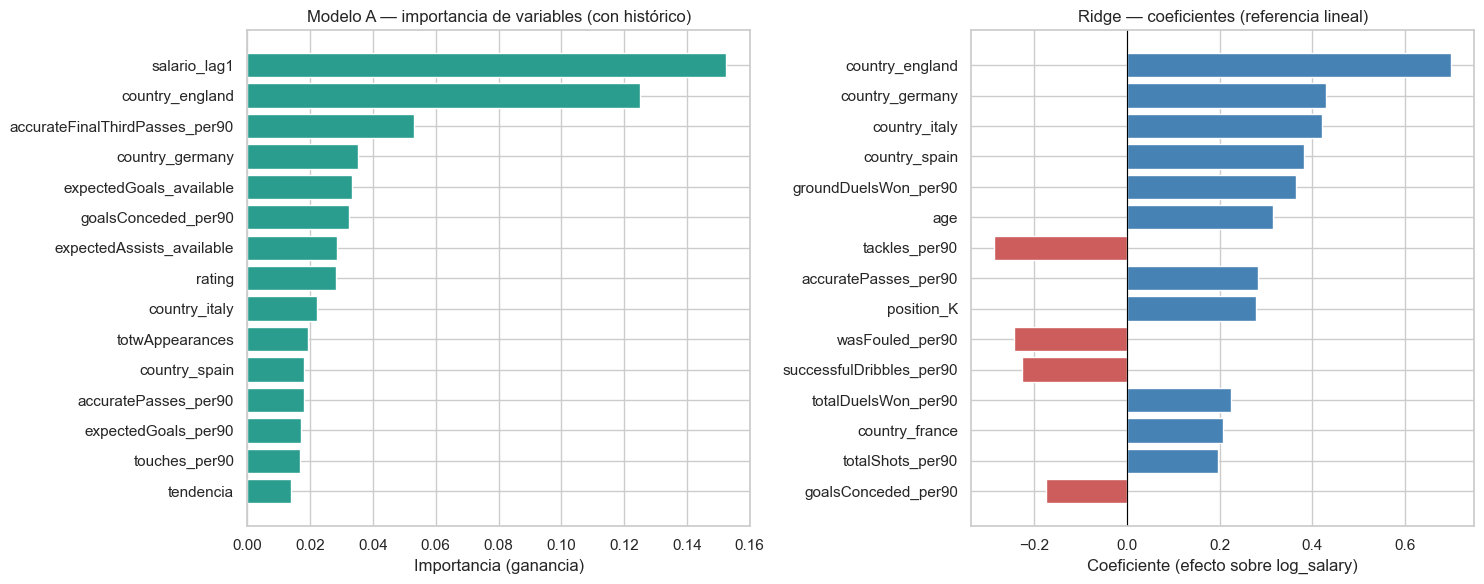

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Importancia de variables del Modelo A (modelo final con histórico)
importancias = pd.Series(modelo_A.feature_importances_, index=XA_tr.columns).sort_values(ascending=False)
top_imp = importancias.head(15)[::-1]
axes[0].barh(top_imp.index, top_imp.values, color='#2a9d8f')
axes[0].set_title('Modelo A — importancia de variables (con histórico)')
axes[0].set_xlabel('Importancia (ganancia)')

# (b) Coeficientes de Ridge (referencia lineal)
ridge_model = ridge_ref.named_steps['ridge']
coefs = pd.Series(ridge_model.coef_, index=XB_tr.columns).sort_values(key=abs, ascending=False)
top_coef = coefs.head(15)[::-1]
colors = ['steelblue' if c>0 else 'indianred' for c in top_coef.values]
axes[1].barh(top_coef.index, top_coef.values, color=colors)
axes[1].set_title('Ridge — coeficientes (referencia lineal)')
axes[1].set_xlabel('Coeficiente (efecto sobre log_salary)')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

**Lectura de los principales factores.**

- **`salario_lag1`** domina la importancia del Modelo A: el sueldo del año anterior es, con diferencia, el
  mejor predictor del salario actual (los sueldos cambian poco de un año a otro).
- **Edad** (`age`): el modelo capta la relación entre edad y salario, de forma no lineal (el salario crece
  con la edad hasta un pico en torno a los 28-30 años y luego decrece). XGBoost aprende esta curvatura
  directamente de `age`, sin necesidad de un término cuadrático explícito.
- **Liga** (`country_england` +): la Premier League paga sistemáticamente más.
- **Volumen y calidad de pase** (`accuratePasses` +): proxy de centralidad en el juego, premiado.

Que `salario_lag1` sea la variable más importante explica por qué el Modelo A es tan superior, y a la vez
matiza su naturaleza: incorpora la inercia salarial, no solo el rendimiento puro.

## 9. Detección de sobre/infravalorados

El residuo del modelo (salario real − estimado) identifica desajustes: residuo positivo → posible
sobrevaloración; negativo → posible infravaloración. Se usan predicciones *out-of-fold* del modelo
combinado sobre todo el dataset, centrándose en la temporada actual (25/26).

In [12]:
# Predicción out-of-fold del modelo combinado sobre TODO el dataset (honesta).
predA_full = cross_val_predict(xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist'),
                               reg[reg['tiene_hist']].drop(columns=[c for c in drop_base if c in reg.columns]),
                               reg[reg['tiene_hist']]['log_salary'].values,
                               groups=reg[reg['tiene_hist']]['_pid'], cv=gkf)
predB_full = cross_val_predict(xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist'),
                               reg.drop(columns=[c for c in drop_base + hist_cols if c in reg.columns]),
                               reg['log_salary'].values, groups=reg['_pid'], cv=gkf)

pred_oof = np.empty(len(reg))
pred_oof[reg['tiene_hist'].values]    = predA_full
pred_oof[(~reg['tiene_hist']).values] = predB_full[(~reg['tiene_hist']).values]

# Construir tabla de resultados cruzando con metadatos por (player_id, season)
res_all = reg[['_pid','_season','log_salary']].copy()
res_all.columns = ['player_id','season','log_salary']
res_all['salario_real'] = np.exp(res_all['log_salary'])
res_all['salario_pred'] = np.exp(pred_oof)
res_all['residuo'] = np.log(res_all['salario_real']) - np.log(res_all['salario_pred'])
res_all = res_all.merge(meta[['player_id','season','player','position','team','country']],
                        on=['player_id','season'], how='left')

res = res_all[res_all['season']=='2526'].copy()

def fmt(df):
    df = df.copy()
    df['real_M€'] = (df['salario_real']/1e6).round(2)
    df['pred_M€'] = (df['salario_pred']/1e6).round(2)
    return df[['player','position','team','real_M€','pred_M€']]

print('=== TOP 12 INFRAVALORADOS 25/26 (cobran menos de lo predicho) ===')
display(fmt(res.nsmallest(12, 'residuo')))
print('\n=== TOP 12 SOBREVALORADOS 25/26 (cobran más de lo predicho) ===')
display(fmt(res.nlargest(12, 'residuo')))

=== TOP 12 INFRAVALORADOS 25/26 (cobran menos de lo predicho) ===


,player,position,team,real_M€,pred_M€
10442,Lyle Foster,F,Burnley,0.05,3.51
12699,Hannibal Mejbri,F,Burnley,0.03,1.86
14139,Harrison Armstrong,M,Everton,0.07,1.68
13976,Jacobo Ramón,D,Como,0.30,2.62
1368,Gökhan Değirmenci,K,Kocaelispor,0.09,0.79
14176,Yan Diomande,F,RB Leipzig,0.75,5.96
288,Santi Cazorla,M,Real Oviedo,0.19,1.51
3661,Taskin Ilter,M,Eyüpspor,0.08,0.58
13950,Miguel Román,M,Celta Vigo,0.25,1.80
6524,Ahmet Oğuz,D,Kocaelispor,0.13,0.89



=== TOP 12 SOBREVALORADOS 25/26 (cobran más de lo predicho) ===


,player,position,team,real_M€,pred_M€
13680,Jorrel Hato,D,Chelsea,7.23,0.90
12037,Philipp Treu,D,SC Freiburg,2.45,0.35
4464,Morgan Sanson,M,Nice,5.09,0.74
4326,N'Golo Kante,M,Fenerbahçe,6.88,1.01
13978,Franco Mastantuono,F,Real Madrid,7.29,1.13
13353,Mohamed Amoura,F,VfL Wolfsburg,4.72,0.74
10464,Kerem Aktürkoğlu,F,Fenerbahçe,5.94,0.96
7887,Gabriel Suazo,D,Sevilla,4.00,0.69
13509,Jordy Makengo,D,SC Freiburg,3.02,0.52
11571,Quinten Timber,M,Olympique de Marseille,4.55,0.83


## 10. Ejemplos comentados

In [13]:
def mostrar(nombre):
    m = res[res['player'].str.contains(nombre, case=False, na=False, regex=False)]
    for _, r in m.iterrows():
        tipo = 'INFRAVALORADO' if r['residuo']<0 else 'SOBREVALORADO'
        print(f"  {r['player']} ({r['position']}, {r['team']}): "
              f"real {r['salario_real']/1e6:.1f}M€ vs predicho {r['salario_pred']/1e6:.1f}M€ → {tipo}")

for nombre in ['Cazorla','Oblak','Nico Williams','Cubarsí','Yamal']:
    mostrar(nombre)

  Santi Cazorla (M, Real Oviedo): real 0.2M€ vs predicho 1.5M€ → INFRAVALORADO
  Jan Oblak (K, Atlético Madrid): real 20.8M€ vs predicho 14.5M€ → SOBREVALORADO
  Nico Williams (F, Athletic Club): real 16.7M€ vs predicho 7.3M€ → SOBREVALORADO
  Pau Cubarsí (D, FC Barcelona): real 4.0M€ vs predicho 7.2M€ → INFRAVALORADO
  Lamine Yamal (F, FC Barcelona): real 16.7M€ vs predicho 7.8M€ → SOBREVALORADO


**Interpretación de los patrones:**

- **Veteranos en equipos modestos** (Cazorla en el Oviedo): aparecen como *infravalorados* — rinden por encima de lo que su salario (bajo, propio de un club recién ascendido) reflejaría.
- **Estrellas consagradas** (Nico Williams, Oblak): aparecen como *sobrevalorados* porque su salario incorpora factores que el modelo no observa (marca, valor de mercado, expectativas, fiabilidad). El residuo grande **no es un error del modelo**: es la señal de que su salario responde a algo más que el rendimiento de una temporada.
- **Jóvenes de élite ya con contrato alto** (Yamal, Cubarsí): pese a su juventud, sus clubes ya les han renovado con fichas elevadas, por lo que el modelo —que solo ve el rendimiento de la temporada— los marca como *sobrevalorados*. Ilustra el límite del enfoque: el salario anticipa un potencial futuro que las stats actuales todavía no respaldan del todo.
- **Porteros de élite** (Oblak): el modelo tiende a infravalorar su rendimiento, por lo que sus fichas reales los sitúan como sobrevalorados; su salario premia trayectoria y fiabilidad más que las stats de una temporada concreta.

## 11. Exportación del artefacto para la plataforma

Se exporta `salarios_predichos.csv` con las predicciones del **modelo combinado**: ambos modelos se
reentrenan con todos sus datos (una vez validados) y se combinan las predicciones según cada jugador tenga
o no histórico. El artefacto conserva la **misma estructura** (14.184 filas; `player_id`, `season`,
`salario_real`, `salario_predicho`, `residuo`)

In [14]:
# --- MODELOS DE PRODUCCIÓN: reentrenar con todos los datos y combinar ---
# Modelo A: todos los jugadores con histórico
prodA = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist')
XA_full = reg[reg['tiene_hist']].drop(columns=[c for c in drop_base if c in reg.columns])
prodA.fit(XA_full, reg[reg['tiene_hist']]['log_salary'].values)

# Modelo B: todos los jugadores (solo rendimiento)
prodB = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, tree_method='hist')
XB_full = reg.drop(columns=[c for c in drop_base + hist_cols if c in reg.columns])
prodB.fit(XB_full, reg['log_salary'].values)

# Predicción combinada
pred_log = np.empty(len(reg))
pred_log[reg['tiene_hist'].values]    = prodA.predict(XA_full)
pred_log[(~reg['tiene_hist']).values] = prodB.predict(XB_full[(~reg['tiene_hist']).values])

salarios_predichos = pd.DataFrame({
    'player_id':        reg['_pid'].values,
    'season':           reg['_season'].values,
    'salario_real':     np.exp(reg['log_salary'].values),
    'salario_predicho': np.exp(pred_log),
})
salarios_predichos['residuo'] = (
    np.log(salarios_predichos['salario_real']) - np.log(salarios_predichos['salario_predicho'])
)
salarios_predichos = salarios_predichos.sort_values(['player_id','season']).reset_index(drop=True)

OUT_PATH = ROOT / 'data' / 'modeling' / 'regression' / 'salarios_predichos.csv'
salarios_predichos.to_csv(OUT_PATH, index=False)
print(f'Predicciones combinadas exportadas: {len(salarios_predichos):,} filas')
print(f'Ruta: {OUT_PATH}')
salarios_predichos.head()

Predicciones combinadas exportadas: 14,184 filas
Ruta: d:\USER\Desktop\TFM\data\modeling\regression\salarios_predichos.csv


,player_id,season,salario_real,salario_predicho,residuo
0,273,2021,3400000.0,2.415109e+06,0.342031
1,518,2021,7200000.0,4.252849e+06,0.526492
2,750,2021,57410000.0,2.395144e+07,0.874190
3,750,2122,31023864.0,2.966721e+07,0.044714
4,750,2223,31023864.0,2.624832e+07,0.167155


## 12. Conclusiones

- Se ha modelado el salario de los futbolistas siguiendo una metodología rigurosa: **partición train/test
  por jugador**, **validación cruzada GroupKFold** dentro de *train* y **búsqueda de hiperparámetros**
  (Optuna) sin fuga de información.
- Partiendo solo de variables de **rendimiento**, **XGBoost** (optimizado) se impone a Ridge, Lasso y
  Random Forest, con un R² ≈ 0.60 en test.
- La incorporación del **histórico salarial** (sueldo del año anterior y tendencia) mejora sustancialmente
  la predicción. Como no todos los jugadores tienen histórico, se adopta un esquema de **dos modelos
  especializados** (con/sin histórico) cuya combinación alcanza un **R² ≈ 0.73 en test**.
- La variable más determinante es el **salario del año anterior**, lo que refleja la fuerte inercia
  salarial del mercado; el rendimiento, la edad y la liga completan los factores clave.
- El **residuo** del modelo (salario real − estimado) constituye el producto analítico central: identifica
  jugadores **infravalorados** (chollos potenciales) y **sobrevalorados**, y alimenta el sistema de
  recomendación de la plataforma.